### Data preparaion

In [1]:
!pip install ipywidgets 

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 8.4 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('superstore_dataset.csv', encoding='latin-1')
print(df.shape)
df.info()


(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

In [2]:
df = df.drop_duplicates()
df['Postal Code'] = df['Postal Code'].fillna(0)

date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])
    
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')


### Deep-Dive Exploratory 

In [3]:
from ipywidgets import interact, Dropdown

categories = ['All'] + list(df['Category'].unique())

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))
    monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
    monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

    if category == 'All':
        total_sales = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_sales.index.to_timestamp(), total_sales.values, marker='o')
    else:
        cat_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(cat_data['Date'], cat_data['Sales'], marker='o')

    plt.title(f'Monthly Sales Trend - {category}')
    plt.xlabel('Date'); plt.ylabel('Sales ($)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

interact(plot_monthly_sales, category=Dropdown(options=categories))


interactive(children=(Dropdown(description='category', options=('All', 'Furniture', 'Office Supplies', 'Techno…

<function __main__.plot_monthly_sales(category='All')>

In [ ]:
state_sales = df.groupby('State')['Sales'].sum().sort_values()

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))
    top_states = state_sales.tail(top_n)
    plt.barh(top_states.index, top_states.values, color='steelblue')
    plt.title(f'Top {top_n} States by Sales')
    plt.xlabel('Sales ($)')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

interact(plot_top_states, top_n=IntSlider(min=5, max=25, value=10))


interactive(children=(IntSlider(value=10, description='top_n', max=25, min=5), Output()), _dom_classes=('widge…

<function __main__.plot_top_states(top_n=10)>

### Top 10 Most Profitable Products

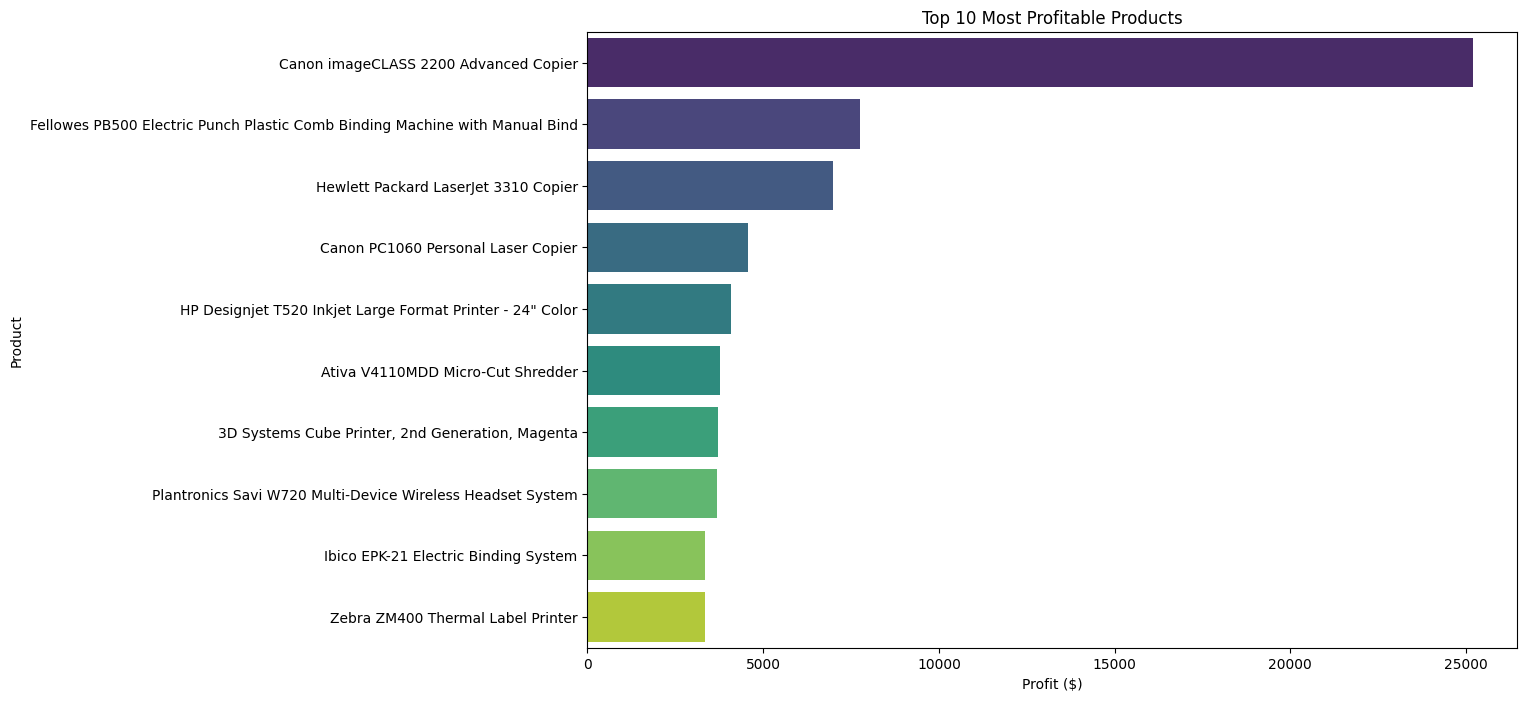

In [7]:
product_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10)
plt.figure(figsize=(12, 8))
sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis')
plt.title('Top 10 Most Profitable Products')
plt.xlabel('Profit ($)'); plt.ylabel('Product')
plt.show()


### Discount vs Profit (Category Hue)

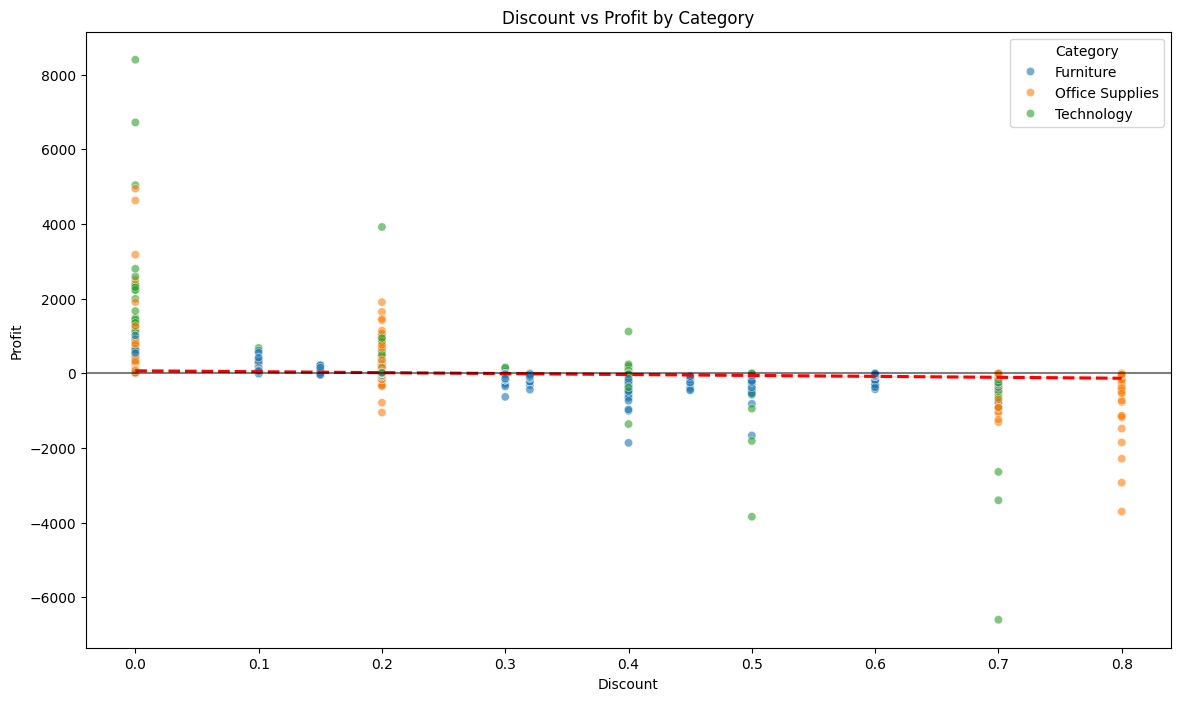

In [10]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linestyle': '--'})
plt.axhline(y=0, color='black', alpha=0.5)
plt.title('Discount vs Profit by Category')
plt.show()

### Executive Summary

In [11]:
print("=== EXECUTIVE SUMMARY ===")
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"• Total Revenue: ${total_sales:,.0f}")
print(f"• Total Profit: ${total_profit:,.0f}")
print(f"• Profit Margin: {profit_margin:.1f}%")
print()
print(f"• Most Profitable Product: {product_profit.index[0]}")
print(f"• Top Performing State: {state_sales.index[-1]}")


=== EXECUTIVE SUMMARY ===
• Total Revenue: $2,297,201
• Total Profit: $286,397
• Profit Margin: 12.5%

• Most Profitable Product: Canon imageCLASS 2200 Advanced Copier
• Top Performing State: California
